In [69]:
%pip install rocketpy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 이란 대함 탄도미사일 3D 비행 궤적 및 탄착점 예측 모델 구축

## 연구 배경과 목적

호르무즈 해협 및 중동 지역의 지정학적 분쟁 심화로 이란 탄도미사일 위협에 대한 감시와 분석의 중요성이 커지고 있습니다. 탄도미사일은 발사 후 도달 시간이 짧기 때문에, 발사 초기 수십 초의 레이더 관측 텔레메트리만으로 최종 탄착점을 추정하는 기술이 필요합니다.

본 연구의 목적은 실제 군사 제원과 비행역학을 참고한 RocketPy 시뮬레이션으로 3차원 합성 궤적 데이터셋을 구축하는 것입니다. 생성된 데이터는 단순한 머신러닝 입력값을 넘어, 바람·질량·공기저항과 같은 불확실성이 궤적과 탄착 오차에 미치는 물리적 영향을 분석하는 데 사용합니다.

이 노트북은 다음 질문에 답하도록 구성되어 있습니다.

- Monte Carlo 입력 변수 중 탄착 오차에 가장 큰 영향을 주는 변수는 무엇인가?
- 네 기종의 마하수, 동압, 고도별 속도 프로파일은 어떻게 다른가?
- 사용자 정의 대기 모델에 따른 대기 밀도 변화가 항력과 가속도에 어떻게 나타나는가?
- 동일 기종 안에서 환경 불확실성이 만드는 탄착점 산포와 CEP는 어느 정도인가?

In [70]:
# 외부 라이브러리
import warnings

import numpy as np
import pandas as pd
from rocketpy import Environment, Flight, Rocket, SolidMotor
from tqdm import tqdm

warnings.filterwarnings("ignore")

## 1. 연구 대상 및 시뮬레이션 제원

이 연구에서는 고체·액체 추진 방식과 단거리·중거리 특성이 다른 이란의 주요 탄도미사일 4종을 비교합니다.

| 미사일명 | 구분 | 추진체 | 전장 (m) | 직경 (m) | 발사 중량 (kg) | 사거리 (km) |
|---|---|---:|---:|---:|---:|---:|
| Khalij Fars | 단거리 대함 (ASBM) | 고체 | 8.9 | 0.61 | 약 3,320 | 300 |
| Qiam-1 | 단거리 지대지 (SRBM) | 액체 | 11.5 | 0.88 | 6,155 | 700~800 |
| Zolfaghar | 중거리 지대지 (MRBM) | 고체 | 10.3 | 0.68 | 4,620 | 700 |
| Shahab-3 | 중거리 지대지 (MRBM) | 액체 | 16.0 | 1.25 | 15,000~16,000 | 1,000~2,000 |

위 표는 연구 대상에 대한 참고 제원입니다. 실제 시뮬레이션에 전달되는 값은 아래 모델 구성 셀의 `MISSILE_SPECS`에 정의되어 있습니다.

In [86]:
# 시뮬레이션 설정
NUM_SIMULATIONS_PER_MISSILE = 10
ENV_LATITUDE = 0.0
ENV_LONGITUDE = 0.0
ENV_ELEVATION = 0.0

# 탄착 오차를 계산할 기준 목표점입니다.
TARGET_X = 0.0
TARGET_Y = 0.0

MISSILE_TYPES = ["Khalij_Fars", "Qiam_1", "Zolfaghar", "Shahab_3"]
OUTPUT_FILE_TEMPLATE = "{}_10K_RealScale.csv"
SUMMARY_FILE_TEMPLATE = "{}_10K_RealScale_Summary.csv"

## 2. 데이터 수집 방법론 및 대기 모델

- **시뮬레이터:** RocketPy 기반 6자유도(6-DOF) 비행역학 시뮬레이터
- **대기 모델:** 표준 대기 모델의 고도 한계를 보완하기 위해 압력은 지수 외삽하고, 온도는 고도 11 km까지 선형 감소한 뒤 일정하게 유지하는 사용자 정의 함수 사용
- **Monte Carlo 변동:** 기상과 기체 불확실성을 매 회차 무작위로 주입
  - 바람 성분 `wind_u`, `wind_v`: 평균 0, 표준편차 10 m/s 정규분포
  - 공기저항계수 변동 `cd_factor`: 0.90~1.10 균등분포
  - 초기 질량 변동 `initial_mass_factor`: 0.95~1.05 균등분포
  - 발사 고각: 60~80도 균등분포
  - 발사 방위각: 0~360도 균등분포

생성된 시계열에는 위치·속도·가속도뿐 아니라 마하수, 동압, 공기 밀도, 현재 질량, 항력을 저장합니다. 따라서 궤적 결과와 물리 상태를 같은 회차 단위로 연결해 검증할 수 있습니다.

In [72]:
# 사용자 정의 대기 모델
# RocketPy가 고도가 높아져도 압력과 온도를 계산할 수 있도록 단순 지수/선형 모델을 사용합니다.
def custom_pressure(altitude):
    altitude = np.asarray(altitude)
    return 101325.0 * np.exp(-altitude / 8420.0)


def custom_temperature(altitude):
    altitude = np.asarray(altitude)
    return np.where(altitude < 11000.0, 288.15 - 0.0065 * altitude, 216.65)

## 3. 기종별 모델 및 시뮬레이션 기준

시뮬레이션 모델은 기종별 반지름, 추진제 질량, 본체 질량, 연소 시간, 추력으로 구성됩니다. 공기저항계수는 기준값 `Cd = 0.3`에 `cd_factor`를 곱해 회차별로 변화시킵니다.

| 미사일명 | 시뮬레이션 직경 (m) | 본체 질량 (kg, 모터 제외) | 연소 시간 (초) | 최대 추력 (N) | 공기저항계수 |
|---|---:|---:|---:|---:|---:|
| Khalij Fars | 0.60 | 400 (참고 모델) | 12.0 | 30,000 | 0.3 ±10% |
| Qiam-1 | 0.80 | 600 (참고 모델) | 15.0 | 45,000 | 0.3 ±10% |
| Zolfaghar | 0.70 | 500 (참고 모델) | 14.0 | 45,000 | 0.3 ±10% |
| Shahab-3 | 1.20 | 900 (참고 모델) | 20.0 | 70,000 | 0.3 ±10% |

연구 문서의 참고 제원과 코드에 구현된 단순화 모델은 구분해야 합니다. 실제 실행값과 물리 파라미터는 `MISSILE_SPECS` 및 `create_missile` 함수가 결정합니다.

In [73]:
# 기종별 기본 제원
MISSILE_SPECS = {
    "Khalij_Fars": {"radius": 0.305, "propellant_mass": 2200, "dry_mass": 1120, "burn_time": 25.0, "thrust": 200000},
    "Qiam_1": {"radius": 0.44, "propellant_mass": 4500, "dry_mass": 1655, "burn_time": 50.0, "thrust": 250000},
    "Zolfaghar": {"radius": 0.34, "propellant_mass": 3500, "dry_mass": 1120, "burn_time": 40.0, "thrust": 220000},
    "Shahab_3": {"radius": 0.625, "propellant_mass": 12000, "dry_mass": 3000, "burn_time": 70.0, "thrust": 450000},
}


def create_missile(missile_type, mass_variation, drag_variation):
    """변동값을 반영한 RocketPy 미사일 객체를 생성합니다."""
    spec = MISSILE_SPECS[missile_type]
    radius = spec["radius"]
    propellant_mass = spec["propellant_mass"] * mass_variation
    dry_mass = spec["dry_mass"] * mass_variation
    burn_time = spec["burn_time"]
    thrust_curve = [(0, spec["thrust"]), (burn_time, spec["thrust"])]

    grain_inner_radius = radius * 0.2
    grain_outer_radius = radius * 0.9
    grain_density = 1800
    grain_area = np.pi * (grain_outer_radius**2 - grain_inner_radius**2)
    grain_height = propellant_mass / (grain_density * grain_area)
    drag_coefficient = 0.3 * drag_variation

    motor = SolidMotor(
        thrust_source=thrust_curve,
        dry_mass=200.0,
        dry_inertia=(50, 50, 10),
        nozzle_radius=radius * 0.8,
        grain_number=1,
        grain_density=grain_density,
        grain_outer_radius=grain_outer_radius,
        grain_initial_inner_radius=grain_inner_radius,
        grain_initial_height=grain_height,
        grain_separation=0.0,
        grains_center_of_mass_position=grain_height / 2,
        center_of_dry_mass_position=1.0,
        coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

    missile = Rocket(
        radius=radius,
        mass=dry_mass,
        inertia=(2000, 2000, 100),
        power_off_drag=drag_coefficient,
        power_on_drag=drag_coefficient,
        center_of_mass_without_motor=2.0,
        coordinate_system_orientation="tail_to_nose",
    )
    missile.add_motor(motor, position=0)
    missile.add_nose(length=radius * 3, kind="vonKarman", position=3.0)
    missile.add_trapezoidal_fins(
        n=4,
        span=radius * 1.5,
        root_chord=radius * 1.5,
        tip_chord=radius * 0.5,
        position=-1.0,
    )

    return missile, burn_time, drag_coefficient

## 4. 데이터셋 구조 및 수집 단위

각 회차는 `sim_id`로 식별하며, 동일한 `sim_id`의 여러 행이 하나의 비행 시계열을 구성합니다. 시계열 CSV와 별도로 회차당 1행인 Summary CSV를 생성해 EDA에 사용합니다.

- **목표 데이터 규모:** 4개 기종별 10,000회, 총 40,000회 궤적 시퀀스
- **현재 테스트 설정:** `NUM_SIMULATIONS_PER_MISSILE = 10`
- **샘플링:** 발사 후 1초 간격과 최종 비행 시점
- **시계열 타깃:** `Target_X`, `Target_Y`, `Target_T`
- **Summary 타깃:** `target_x`, `target_y`, `flight_time`, `range_error`

현재 설정값 10은 파이프라인 검증용입니다. 연구용 통계 분석에서는 목표 규모에 맞춰 설정값을 늘려야 합니다.

In [87]:
def simulate_flight(missile_type, sim_id):
    """한 회차를 실행하고 시계열 행과 회차 요약을 함께 반환합니다."""
    elevation = np.random.uniform(60, 80)
    azimuth = np.random.uniform(0, 360)

    # 회차별 Monte Carlo 독립 변수
    initial_mass_factor = np.random.uniform(0.95, 1.05)
    cd_factor = np.random.uniform(0.90, 1.10)
    wind_u_scale = np.random.normal(0, 10.0)
    wind_v_scale = np.random.normal(0, 10.0)
    wind_speed = np.sqrt(wind_u_scale**2 + wind_v_scale**2)
    wind_direction = (
        np.degrees(np.arctan2(wind_v_scale, wind_u_scale)) + 360
    ) % 360

    environment = Environment(
        latitude=ENV_LATITUDE,
        longitude=ENV_LONGITUDE,
        elevation=ENV_ELEVATION,
    )
    environment.set_atmospheric_model(
        type="custom_atmosphere",
        pressure=custom_pressure,
        temperature=custom_temperature,
        wind_u=wind_u_scale,
        wind_v=wind_v_scale,
    )

    missile, burn_time, drag_coefficient = create_missile(
        missile_type,
        initial_mass_factor,
        cd_factor,
    )
    reference_area = np.pi * MISSILE_SPECS[missile_type]["radius"] ** 2
    flight = Flight(
        rocket=missile,
        environment=environment,
        rail_length=10.0,
        inclination=elevation,
        heading=azimuth,
        max_time=1200,
        max_time_step=0.5,
    )

    impact_x = flight.x(flight.t_final)
    impact_y = flight.y(flight.t_final)
    flight_time = flight.t_final
    if flight_time < 60.0:
        return [], None

    time_steps = np.append(np.arange(1.0, flight_time, 1.0), flight_time)
    initial_propellant_mass = missile.motor.propellant_initial_mass
    total_dry_mass = missile.mass + missile.motor.dry_mass
    rows = []

    max_altitude = -np.inf
    max_mach = -np.inf
    max_dynamic_pressure = -np.inf
    max_drag_force = -np.inf

    for time in time_steps:
        current_mass = total_dry_mass
        if time < burn_time:
            current_mass += initial_propellant_mass * (1 - time / burn_time)

        vx, vy, vz = flight.vx(time), flight.vy(time), flight.vz(time)
        speed = np.sqrt(vx**2 + vy**2 + vz**2)
        altitude = flight.z(time)

        # 현재 고도의 대기 상태와 항공역학 물리량을 계산합니다.
        weather_pressure = float(custom_pressure(altitude))
        weather_temperature = float(custom_temperature(altitude))
        weather_air_density = weather_pressure / (287.05 * weather_temperature)
        mach = speed / 340.3
        dynamic_pressure = 0.5 * weather_air_density * speed**2
        drag_force = dynamic_pressure * drag_coefficient * reference_area

        max_altitude = max(max_altitude, altitude)
        max_mach = max(max_mach, mach)
        max_dynamic_pressure = max(max_dynamic_pressure, dynamic_pressure)
        max_drag_force = max(max_drag_force, drag_force)

        try:
            pitch = float(flight.inclination(time))
        except Exception:
            pitch = np.degrees(np.arcsin(vz / (speed + 1e-6)))

        try:
            yaw = float(flight.heading(time))
        except Exception:
            yaw = np.degrees(np.arctan2(vy, vx))

        rows.append({
            "sim_id": sim_id,
            "missile_type": missile_type,
            "time_step": round(time, 2),
            # Monte Carlo 입력 변수: 모든 시계열 행에 회차 메타데이터로 반복 기록
            "wind_u": round(wind_u_scale, 3),
            "wind_v": round(wind_v_scale, 3),
            "wind_u_scale": round(wind_u_scale, 3),
            "wind_v_scale": round(wind_v_scale, 3),
            "cd_factor": round(cd_factor, 5),
            "initial_mass_factor": round(initial_mass_factor, 5),
            "launch_elevation": round(elevation, 3),
            "launch_azimuth": round(azimuth, 3),
            # 환경 메타데이터
            "weather_wind_speed": round(wind_speed, 3),
            "weather_wind_direction_deg": round(wind_direction, 3),
            "weather_pressure": round(weather_pressure, 3),
            "weather_temperature": round(weather_temperature, 3),
            "weather_air_density": round(weather_air_density, 6),
            # 위치, 속도, 가속도
            "x": flight.x(time), "y": flight.y(time), "z": altitude,
            "vx": vx, "vy": vy, "vz": vz,
            "ax": flight.ax(time), "ay": flight.ay(time), "az": flight.az(time),
            "pitch": pitch, "yaw": yaw,
            # 주요 물리 변수
            "mach": mach,
            "dynamic_pressure": dynamic_pressure,
            "air_density": weather_air_density,
            "current_mass": round(current_mass, 2),
            "drag_force": drag_force,
            # 최종 결과: 한 회차의 모든 행에서 동일
            "Target_X": impact_x,
            "Target_Y": impact_y,
            "Target_T": flight_time,
        })

    summary = {
        "sim_id": sim_id,
        "missile_type": missile_type,
        "wind_u": wind_u_scale,
        "wind_v": wind_v_scale,
        "wind_u_scale": wind_u_scale,
        "wind_v_scale": wind_v_scale,
        "cd_factor": cd_factor,
        "initial_mass_factor": initial_mass_factor,
        "launch_elevation": elevation,
        "launch_azimuth": azimuth,
        "apogee_z": max_altitude,
        "max_mach": max_mach,
        "max_q": max_dynamic_pressure,
        "max_drag_force": max_drag_force,
        "flight_time": flight_time,
        "target_x": impact_x,
        "target_y": impact_y,
        "range_error": np.hypot(impact_x - TARGET_X, impact_y - TARGET_Y),
    }
    return rows, summary


def generate_dataset(missile_type):
    """한 기종의 시계열 데이터와 회차별 요약 데이터를 생성합니다."""
    time_series_rows = []
    summary_rows = []
    simulation_id = 1

    with tqdm(total=NUM_SIMULATIONS_PER_MISSILE, desc=missile_type) as progress:
        while simulation_id <= NUM_SIMULATIONS_PER_MISSILE:
            try:
                simulation_rows, simulation_summary = simulate_flight(
                    missile_type,
                    simulation_id,
                )
                if not simulation_rows:
                    continue

                time_series_rows.extend(simulation_rows)
                summary_rows.append(simulation_summary)
                simulation_id += 1
                progress.update(1)
            except Exception:
                # 실패한 회차는 카운트하지 않고 같은 sim_id로 재시도합니다.
                continue

    return pd.DataFrame(time_series_rows), pd.DataFrame(summary_rows)

## 5. 분석 목표

이후 셀에서는 RocketPy 내부 계산 결과와 생성된 데이터의 관계를 다음 네 가지 관점에서 분석합니다.

1. **Sensitivity Analysis:** `wind_u`, `wind_v`, `cd_factor`, `initial_mass_factor` 중 `Target_X`, `Target_Y`, `range_error`에 가장 큰 영향을 주는 변수를 확인합니다.
2. **Comparative Analysis:** `Khalij_Fars`, `Qiam_1`, `Zolfaghar`, `Shahab_3`의 최대 마하수, 최대 동압, 고도별 속도 프로파일을 비교합니다.
3. **Descriptive Analysis:** `custom_pressure`, `custom_temperature`로 계산한 대기 밀도 변화가 항력과 가속도에 미치는 물리적 관계를 확인합니다.
4. **Uncertainty & Scatter Analysis:** 동일 기종의 탄착점 산포, CEP, `range_error` 확률분포를 비교합니다.

In [88]:
# 기종별 시계열 데이터와 회차별 요약 데이터 생성 및 저장
print(
    f"기종별 {NUM_SIMULATIONS_PER_MISSILE}개, "
    f"총 {len(MISSILE_TYPES) * NUM_SIMULATIONS_PER_MISSILE}개 시뮬레이션을 시작합니다.\n"
)

for missile_type in MISSILE_TYPES:
    print(f"[{missile_type}] 궤적 및 요약 데이터 생성 중...")
    time_series, summary = generate_dataset(missile_type)

    time_series_file = OUTPUT_FILE_TEMPLATE.format(missile_type)
    summary_file = SUMMARY_FILE_TEMPLATE.format(missile_type)
    time_series.to_csv(time_series_file, index=False)
    summary.to_csv(summary_file, index=False)

    print(f"시계열 저장: {time_series_file} ({len(time_series):,}행)")
    print(f"요약 저장: {summary_file} ({len(summary):,}행)\n")

print("모든 시계열 및 회차별 요약 데이터셋 생성이 완료되었습니다.")

기종별 10개, 총 40개 시뮬레이션을 시작합니다.

[Khalij_Fars] 궤적 및 요약 데이터 생성 중...


Khalij_Fars: 100%|██████████| 10/10 [00:06<00:00,  1.64it/s]


시계열 저장: Khalij_Fars_10K_RealScale.csv (3,014행)
요약 저장: Khalij_Fars_10K_RealScale_Summary.csv (10행)

[Qiam_1] 궤적 및 요약 데이터 생성 중...


Qiam_1: 100%|██████████| 10/10 [00:09<00:00,  1.07it/s]


시계열 저장: Qiam_1_10K_RealScale.csv (3,106행)
요약 저장: Qiam_1_10K_RealScale_Summary.csv (10행)

[Zolfaghar] 궤적 및 요약 데이터 생성 중...


Zolfaghar: 100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


시계열 저장: Zolfaghar_10K_RealScale.csv (3,985행)
요약 저장: Zolfaghar_10K_RealScale_Summary.csv (10행)

[Shahab_3] 궤적 및 요약 데이터 생성 중...


Shahab_3: 100%|██████████| 10/10 [00:11<00:00,  1.17s/it]

시계열 저장: Shahab_3_10K_RealScale.csv (2,847행)
요약 저장: Shahab_3_10K_RealScale_Summary.csv (10행)

모든 시계열 및 회차별 요약 데이터셋 생성이 완료되었습니다.


## 6. 수집 데이터의 물리적 의미

시계열 데이터는 한 회차의 비행을 시간축으로 기록합니다.

- **상태 변수:** `x`, `y`, `z`, `vx`, `vy`, `vz`, `ax`, `ay`, `az`
- **비행 물리량:** `mach`, `dynamic_pressure`, `current_mass`, `drag_force`
- **대기 변수:** `weather_pressure`, `weather_temperature`, `weather_air_density`
- **Monte Carlo 입력:** `wind_u`, `wind_v`, `cd_factor`, `initial_mass_factor`, `launch_elevation`, `launch_azimuth`
- **회차 결과:** `Target_X`, `Target_Y`, `Target_T`

항력은 동압과 기준 면적을 이용해 $D = q C_d A$로 계산합니다. 동압은 $q = \frac{1}{2}\rho v^2$이며, 여기서 $\rho$는 사용자 정의 대기 모델로부터 계산한 공기 밀도입니다.

Summary 데이터는 각 회차를 1행으로 압축합니다. `apogee_z`, `max_mach`, `max_q`, `max_drag_force`는 시계열에서 추출한 최대값이며, `range_error`는 기준 목표점과 최종 탄착점 사이의 거리입니다.

## 7. 분석용 파일과 결과 해석

기종별로 다음 두 종류의 파일이 생성됩니다.

- `*_10K_RealScale.csv`: 1초 간격의 비행 시계열 데이터
- `*_10K_RealScale_Summary.csv`: 회차당 1행인 비행 요약 데이터

시계열 데이터는 고도에 따른 속도·마하수·동압·대기 밀도·항력 변화를 확인하는 데 사용합니다. Summary 데이터는 Monte Carlo 입력 변수와 최종 탄착 결과를 연결해 상관관계, 민감도, 기종별 분포, CEP를 계산하는 데 사용합니다.

분석 결과는 단순히 상관계수가 큰 변수를 나열하는 데 그치지 않고, RocketPy의 질량 감소·대기 밀도·항력·가속도 계산이 생성된 데이터에 물리적으로 반영되었는지 확인하는 방향으로 해석합니다.

In [98]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 운영체제에 설치된 한글 폰트를 찾아 matplotlib 전체 그래프에 적용합니다.
korean_font_candidates = [
    "AppleGothic",
    "NanumGothic",
    "Malgun Gothic",
    "Noto Sans CJK KR",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (font for font in korean_font_candidates if font in available_fonts),
    None,
)
if korean_font is None:
    raise RuntimeError(
        "한글 폰트를 찾지 못했습니다. AppleGothic 또는 NanumGothic을 설치해 주세요."
    )

plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False
print(f"matplotlib 한글 폰트: {korean_font}")

# 시계열 분석에 필요한 물리 변수와 환경 변수를 읽습니다.
trajectory_columns = [
    "sim_id",
    "missile_type",
    "time_step",
    "x",
    "y",
    "z",
    "vx",
    "vy",
    "vz",
    "ax",
    "ay",
    "az",
    "mach",
    "dynamic_pressure",
    "drag_force",
    "current_mass",
    "weather_wind_speed",
    "weather_temperature",
    "weather_pressure",
    "weather_air_density",
    "Target_X",
    "Target_Y",
    "Target_T",
]

csv_files = sorted(Path(".").glob("*_10K_RealScale.csv"))
summary_files = sorted(Path(".").glob("*_10K_RealScale_Summary.csv"))
if not csv_files or not summary_files:
    raise FileNotFoundError(
        "시계열 CSV 또는 Summary CSV 파일을 찾지 못했습니다. 먼저 데이터 생성 셀을 실행해 주세요."
    )

trajectory_frames = []
for csv_file in csv_files:
    frame = pd.read_csv(csv_file, usecols=trajectory_columns)
    if "missile_type" not in frame:
        frame["missile_type"] = csv_file.stem.replace("_10K_RealScale", "")
    trajectory_frames.append(frame)

summary_frames = []
for summary_file in summary_files:
    frame = pd.read_csv(summary_file)
    if "missile_type" not in frame:
        frame["missile_type"] = summary_file.stem.replace(
            "_10K_RealScale_Summary", ""
        )
    summary_frames.append(frame)

trajectory_data = pd.concat(trajectory_frames, ignore_index=True)
summary_data = pd.concat(summary_frames, ignore_index=True)

print(f"시계열 행 수: {len(trajectory_data):,}")
print(f"Summary 회차 수: {len(summary_data):,}")
summary_data.head()

matplotlib 한글 폰트: AppleGothic
시계열 행 수: 12,952
Summary 회차 수: 40


,sim_id,missile_type,wind_u,wind_v,wind_u_scale,wind_v_scale,cd_factor,initial_mass_factor,launch_elevation,launch_azimuth,apogee_z,max_mach,max_q,max_drag_force,flight_time,target_x,target_y,range_error
0,1,Khalij_Fars,1.676612,12.078084,1.676612,12.078084,0.986352,1.004395,65.679814,332.148416,114220.999938,5.199241,787527.506256,68103.348546,324.083858,-190895.834499,201000.378037,277204.566340
1,2,Khalij_Fars,13.640347,16.345559,13.640347,16.345559,0.939359,1.042596,70.292598,262.515669,54729.594113,4.996054,547276.172110,45072.236677,227.642326,-213629.640106,-102954.069790,237143.761500
2,3,Khalij_Fars,27.042740,14.797233,27.042740,14.797233,0.976582,0.951199,65.045622,133.016660,82425.343011,5.382999,631097.772808,54035.105766,278.797217,-16789.442906,-303097.447603,303562.099309
3,4,Khalij_Fars,1.522182,9.758746,1.522182,9.758746,1.078385,0.950028,61.673760,59.648497,93943.874900,5.366192,621072.496158,58720.126232,299.278260,291402.726262,95608.000935,306686.221921
4,5,Khalij_Fars,-9.557205,3.167785,-9.557205,3.167785,1.023285,0.996492,76.347208,76.779912,114851.756197,5.197949,742916.024558,66651.093922,328.590470,277408.733804,13433.066395,277733.780558


In [99]:
# 분석용 공통 전처리
terminal_data = summary_data.copy()
terminal_data["target_distance"] = np.hypot(
    terminal_data["target_x"],
    terminal_data["target_y"],
)

trajectory_data["speed"] = np.sqrt(
    trajectory_data["vx"] ** 2
    + trajectory_data["vy"] ** 2
    + trajectory_data["vz"] ** 2
)
trajectory_data["acceleration_magnitude"] = np.sqrt(
    trajectory_data["ax"] ** 2
    + trajectory_data["ay"] ** 2
    + trajectory_data["az"] ** 2
)

weather_sample = trajectory_data.sample(
    n=min(10000, len(trajectory_data)),
    random_state=42,
).sort_values("z")

sensitivity_inputs = [
    "wind_u",
    "wind_v",
    "cd_factor",
    "initial_mass_factor",
]
summary_targets = ["target_x", "target_y", "range_error"]

print(f"시계열 행 수: {len(trajectory_data):,}")
print(f"Summary 회차 수: {len(terminal_data):,}")
terminal_data.head()

시계열 행 수: 12,952
Summary 회차 수: 40


,sim_id,missile_type,wind_u,wind_v,wind_u_scale,wind_v_scale,cd_factor,initial_mass_factor,launch_elevation,launch_azimuth,apogee_z,max_mach,max_q,max_drag_force,flight_time,target_x,target_y,range_error,target_distance
0,1,Khalij_Fars,1.676612,12.078084,1.676612,12.078084,0.986352,1.004395,65.679814,332.148416,114220.999938,5.199241,787527.506256,68103.348546,324.083858,-190895.834499,201000.378037,277204.566340,277204.566340
1,2,Khalij_Fars,13.640347,16.345559,13.640347,16.345559,0.939359,1.042596,70.292598,262.515669,54729.594113,4.996054,547276.172110,45072.236677,227.642326,-213629.640106,-102954.069790,237143.761500,237143.761500
2,3,Khalij_Fars,27.042740,14.797233,27.042740,14.797233,0.976582,0.951199,65.045622,133.016660,82425.343011,5.382999,631097.772808,54035.105766,278.797217,-16789.442906,-303097.447603,303562.099309,303562.099309
3,4,Khalij_Fars,1.522182,9.758746,1.522182,9.758746,1.078385,0.950028,61.673760,59.648497,93943.874900,5.366192,621072.496158,58720.126232,299.278260,291402.726262,95608.000935,306686.221921,306686.221921
4,5,Khalij_Fars,-9.557205,3.167785,-9.557205,3.167785,1.023285,0.996492,76.347208,76.779912,114851.756197,5.197949,742916.024558,66651.093922,328.590470,277408.733804,13433.066395,277733.780558,277733.780558


## 8. Sensitivity Analysis: Monte Carlo 요인과 탄착 오차

바람의 동서·남북 성분, 공기저항계수 변동, 초기 질량 변동을 독립 변수로 사용합니다. 이 변수들이 최종 탄착점 `Target_X`, `Target_Y`와 종합 오차 `range_error`에 어떤 방향과 크기로 연결되는지 Pearson 상관계수로 확인합니다.

상관관계는 선형 영향의 1차 진단이며, 변수의 상대적 영향력을 비교하기 위한 출발점입니다.

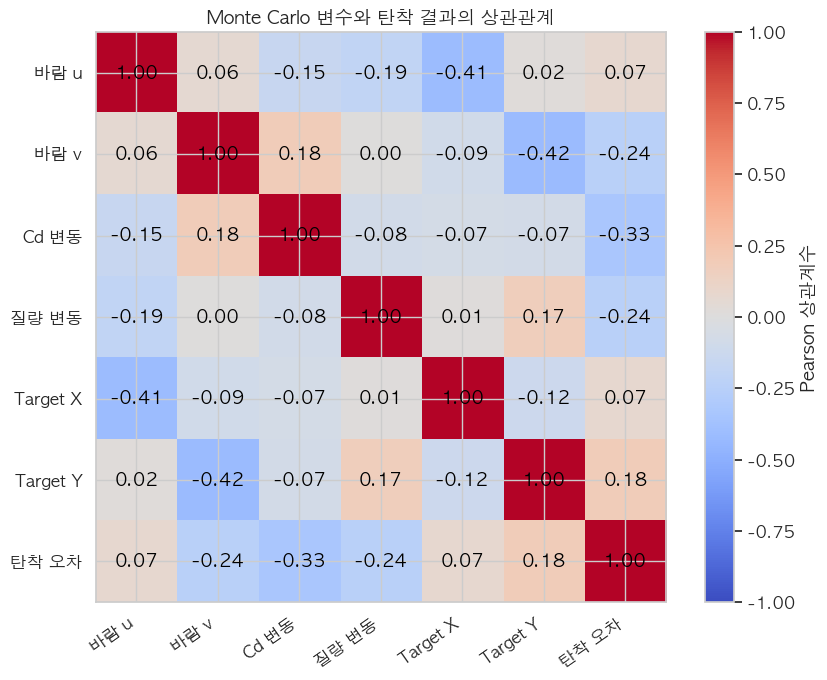

탄착 오차와의 상관계수:
cd_factor             -0.330427
wind_v                -0.237585
initial_mass_factor   -0.236796
target_y               0.185000
target_x               0.074334
wind_u                 0.070705
Name: range_error, dtype: float64


In [93]:
# 1. Monte Carlo 변수와 탄착 결과의 Pearson 상관관계
correlation_columns = sensitivity_inputs + summary_targets
correlation_matrix = terminal_data[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
labels = [
    "바람 u",
    "바람 v",
    "Cd 변동",
    "질량 변동",
    "Target X",
    "Target Y",
    "탄착 오차",
]
ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Monte Carlo 변수와 탄착 결과의 상관관계")

for row in range(len(labels)):
    for column in range(len(labels)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(image, ax=ax, label="Pearson 상관계수")
fig.tight_layout()
plt.show()

print("탄착 오차와의 상관계수:")
print(
    correlation_matrix["range_error"]
    .drop("range_error")
    .sort_values(key=np.abs, ascending=False)
)

## 9. Sensitivity Analysis: 영향 변수 순위

앞 셀의 상관계수를 절댓값 기준으로 정렬해 탄착 오차에 대한 영향력을 비교합니다. 양의 상관은 입력값 증가와 오차 증가가 함께 나타나는 경향을, 음의 상관은 반대 경향을 뜻합니다.

이 결과는 기상 요인과 기체 파라미터 중 무엇을 우선적으로 보정하거나 추가 샘플링해야 하는지 판단하는 근거가 됩니다.

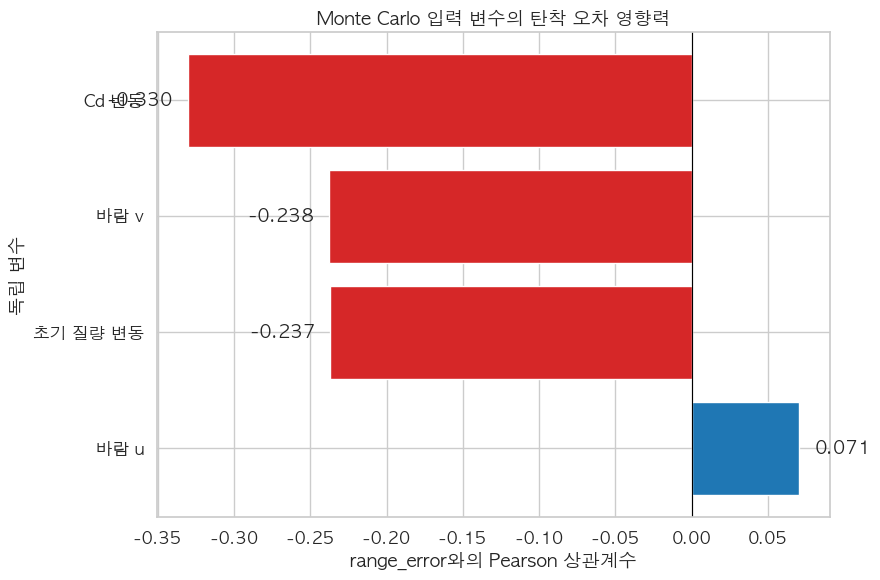

절댓값 기준 영향력 순위:
cd_factor              0.330427
wind_v                 0.237585
initial_mass_factor    0.236796
wind_u                 0.070705
Name: range_error, dtype: float64


In [94]:
# 2. 독립 변수별 탄착 오차 영향력
sensitivity_rank = (
    terminal_data[sensitivity_inputs + ["range_error"]]
    .corr()["range_error"]
    .drop("range_error")
    .sort_values(key=np.abs)
)

label_map = {
    "wind_u": "바람 u",
    "wind_v": "바람 v",
    "cd_factor": "Cd 변동",
    "initial_mass_factor": "초기 질량 변동",
}
plot_labels = [label_map[name] for name in sensitivity_rank.index]
colors = ["tab:blue" if value >= 0 else "tab:red" for value in sensitivity_rank.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_labels, sensitivity_rank.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Monte Carlo 입력 변수의 탄착 오차 영향력")
ax.set_xlabel("range_error와의 Pearson 상관계수")
ax.set_ylabel("독립 변수")

for position, value in enumerate(sensitivity_rank.values):
    ax.text(
        value + (0.01 if value >= 0 else -0.01),
        position,
        f"{value:.3f}",
        va="center",
        ha="left" if value >= 0 else "right",
    )

fig.tight_layout()
plt.show()
print("절댓값 기준 영향력 순위:")
print(sensitivity_rank.abs().sort_values(ascending=False))

## 10. Comparative Analysis: 기종별 최대 마하수

네 기종의 Summary에서 회차별 `max_mach`를 비교합니다. 추진 성능과 질량·형상 차이가 음속 돌파 수준과 회차별 분산에 어떻게 나타나는지 확인합니다.

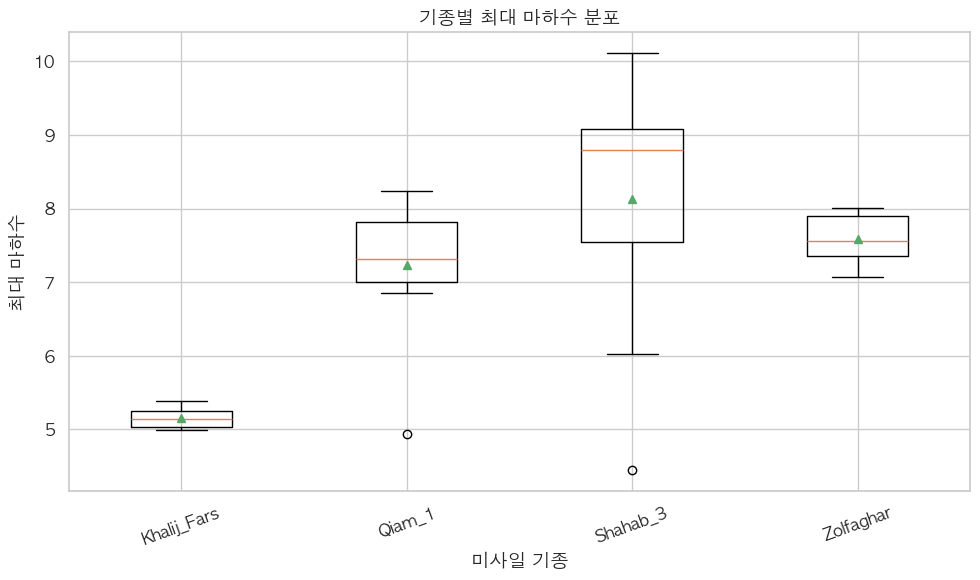

              count      mean       std       min       25%       50%  \
missile_type                                                            
Khalij_Fars    10.0  5.158501  0.146300  4.996054  5.031249  5.136614   
Qiam_1         10.0  7.228714  0.934231  4.944228  7.000470  7.311105   
Shahab_3       10.0  8.133185  1.730935  4.446453  7.547000  8.795859   
Zolfaghar      10.0  7.591709  0.319530  7.074982  7.359385  7.560508   

                   75%        max  
missile_type                       
Khalij_Fars   5.254791   5.382999  
Qiam_1        7.821373   8.244539  
Shahab_3      9.082132  10.113915  
Zolfaghar     7.895314   8.009226  


In [95]:
# 3. 기종별 최대 마하수 분포
missile_order = sorted(terminal_data["missile_type"].unique())
mach_groups = [
    terminal_data.loc[terminal_data["missile_type"] == missile, "max_mach"]
    for missile in missile_order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(mach_groups, labels=missile_order, showmeans=True)
ax.set_title("기종별 최대 마하수 분포")
ax.set_xlabel("미사일 기종")
ax.set_ylabel("최대 마하수")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

print(terminal_data.groupby("missile_type")["max_mach"].describe())

## 11. Comparative Analysis: 기종별 최대 동압

동압 `q = 1/2 rho v^2`는 속도와 대기 밀도의 결합 효과를 나타내는 유체역학 변수입니다. 기종별 `max_q` 분포를 비교해 비행 중 받는 공력 하중의 차이를 확인합니다.

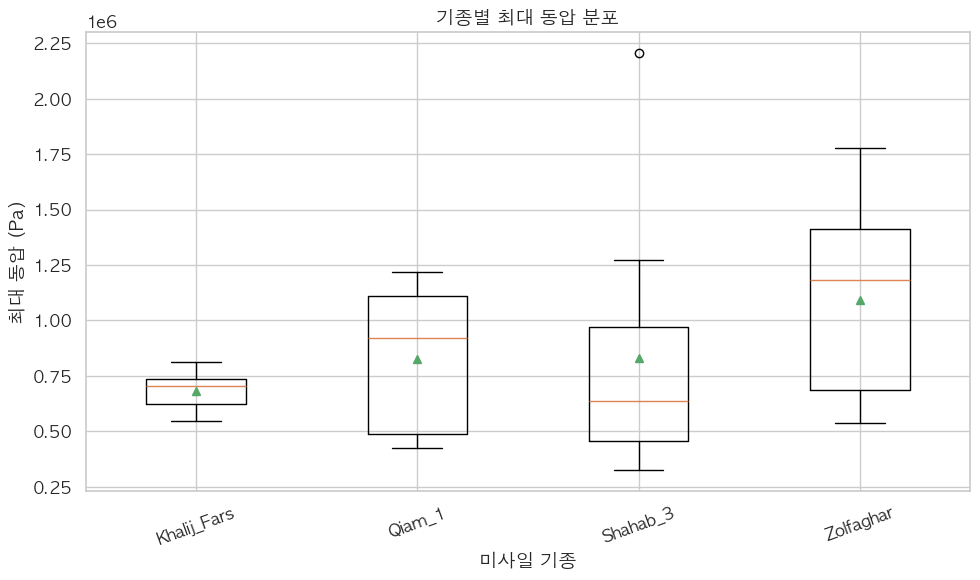

              count          mean            std            min  \
missile_type                                                      
Khalij_Fars    10.0  6.819802e+05   92348.712868  547276.172110   
Qiam_1         10.0  8.240606e+05  330280.142652  422591.587972   
Shahab_3       10.0  8.290668e+05  566146.703423  324395.961131   
Zolfaghar      10.0  1.091699e+06  434011.011241  539385.878874   

                        25%           50%           75%           max  
missile_type                                                           
Khalij_Fars   623578.815321  7.052148e+05  7.360579e+05  8.144392e+05  
Qiam_1        486577.273386  9.190974e+05  1.110962e+06  1.220251e+06  
Shahab_3      456471.802398  6.355301e+05  9.694667e+05  2.206631e+06  
Zolfaghar     686756.171316  1.181308e+06  1.410396e+06  1.779785e+06  


In [96]:
# 4. 기종별 최대 동압 분포
q_groups = [
    terminal_data.loc[terminal_data["missile_type"] == missile, "max_q"]
    for missile in missile_order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(q_groups, labels=missile_order, showmeans=True)
ax.set_title("기종별 최대 동압 분포")
ax.set_xlabel("미사일 기종")
ax.set_ylabel("최대 동압 (Pa)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

print(terminal_data.groupby("missile_type")["max_q"].describe())

## 12. Comparative Analysis: 고도별 속도 프로파일

시계열 데이터에서 동일한 시간 구간의 평균 고도와 평균 속도를 계산합니다. 이 프로파일은 네 기종의 상승·가속·감속 구간이 고도축에서 어떻게 달라지는지 보여줍니다.

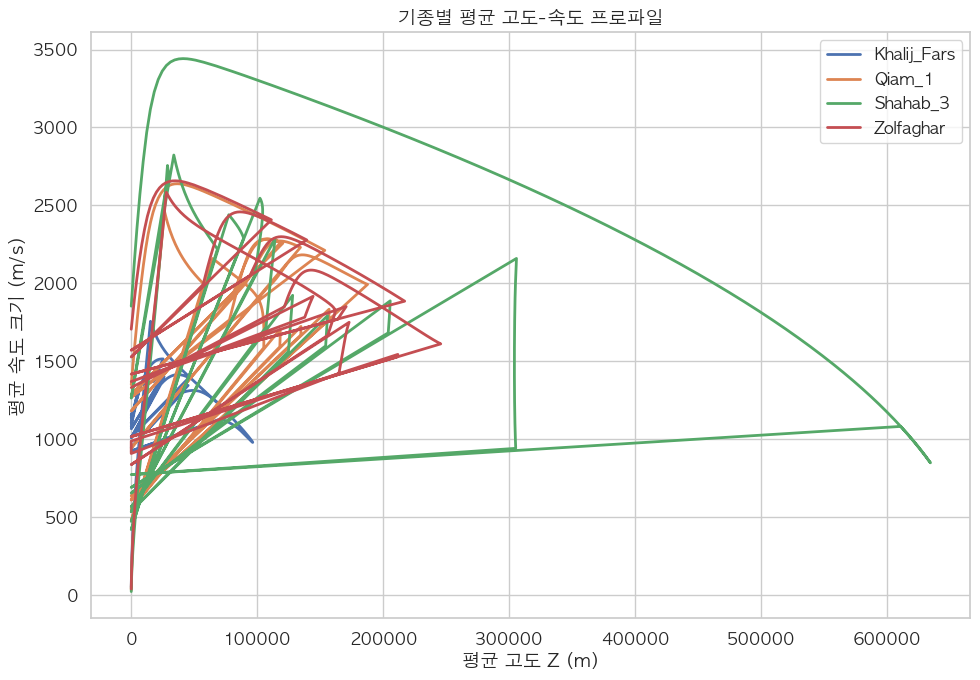

In [100]:
# 5. 기종별 평균 고도-속도 프로파일
profile_data = (
    trajectory_data.groupby(["missile_type", "time_step"], as_index=False)
    .agg(mean_altitude=("z", "mean"), mean_speed=("speed", "mean"))
)

fig, ax = plt.subplots(figsize=(10, 7))
for missile_type, missile_data in profile_data.groupby("missile_type"):
    ax.plot(
        missile_data["mean_altitude"],
        missile_data["mean_speed"],
        linewidth=2,
        label=missile_type,
    )

ax.set_title("기종별 평균 고도-속도 프로파일")
ax.set_xlabel("평균 고도 Z (m)")
ax.set_ylabel("평균 속도 크기 (m/s)")
ax.legend()
fig.tight_layout()
plt.show()

## 13. Descriptive Analysis: 사용자 정의 대기 모델 검증

`custom_pressure`와 `custom_temperature`로 계산한 이론적 대기 밀도 곡선을 시뮬레이션에 실제 기록된 `weather_air_density`와 겹쳐 그립니다. 두 값이 일치하면 대기 모델이 비행 상태 변수에 일관되게 주입되었음을 확인할 수 있습니다.

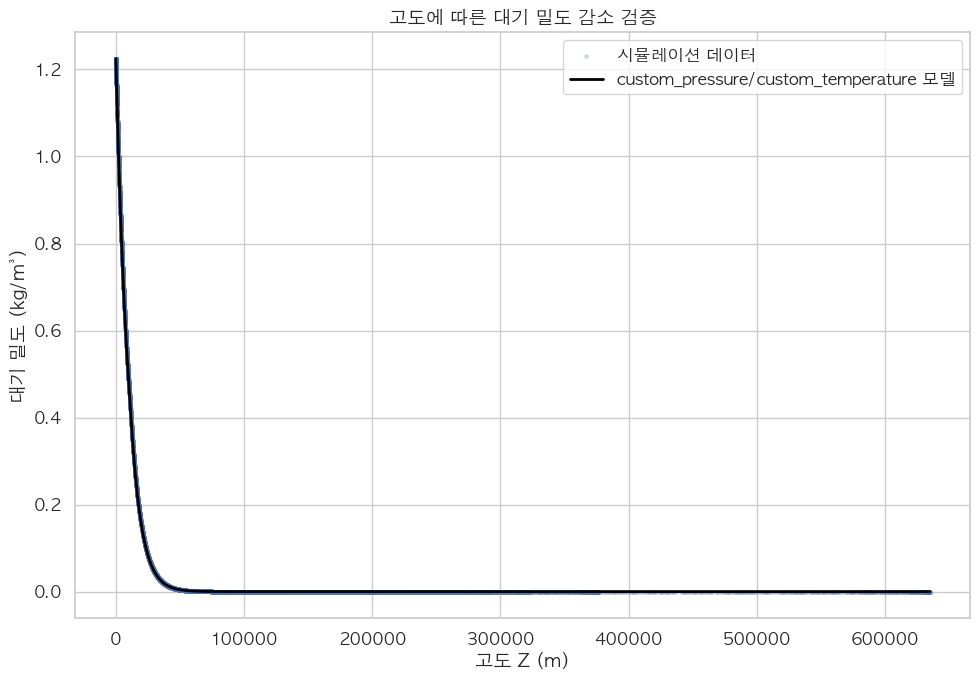

고도-대기밀도 상관계수: -0.39980516599399885


In [101]:
# 6. 시뮬레이션 대기 밀도와 사용자 정의 모델 비교
altitude_grid = np.linspace(
    trajectory_data["z"].min(),
    trajectory_data["z"].max(),
    300,
)
model_pressure = custom_pressure(altitude_grid)
model_temperature = custom_temperature(altitude_grid)
model_density = model_pressure / (287.05 * model_temperature)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    weather_sample["z"],
    weather_sample["weather_air_density"],
    s=6,
    alpha=0.2,
    label="시뮬레이션 데이터",
)
ax.plot(
    altitude_grid,
    model_density,
    color="black",
    linewidth=2,
    label="custom_pressure/custom_temperature 모델",
)
ax.set_title("고도에 따른 대기 밀도 감소 검증")
ax.set_xlabel("고도 Z (m)")
ax.set_ylabel("대기 밀도 (kg/m³)")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "고도-대기밀도 상관계수:",
    trajectory_data[["z", "weather_air_density"]].corr().iloc[0, 1],
)

## 14. Descriptive Analysis: 대기 밀도와 항력

고도가 올라가면 대기 밀도가 낮아지고, 같은 속도 조건에서 항력이 감소하는 경향이 나타납니다. 시계열의 `weather_air_density`와 `drag_force` 관계를 확인해 $D = q C_d A$ 계산이 데이터에 반영되었는지 검증합니다.

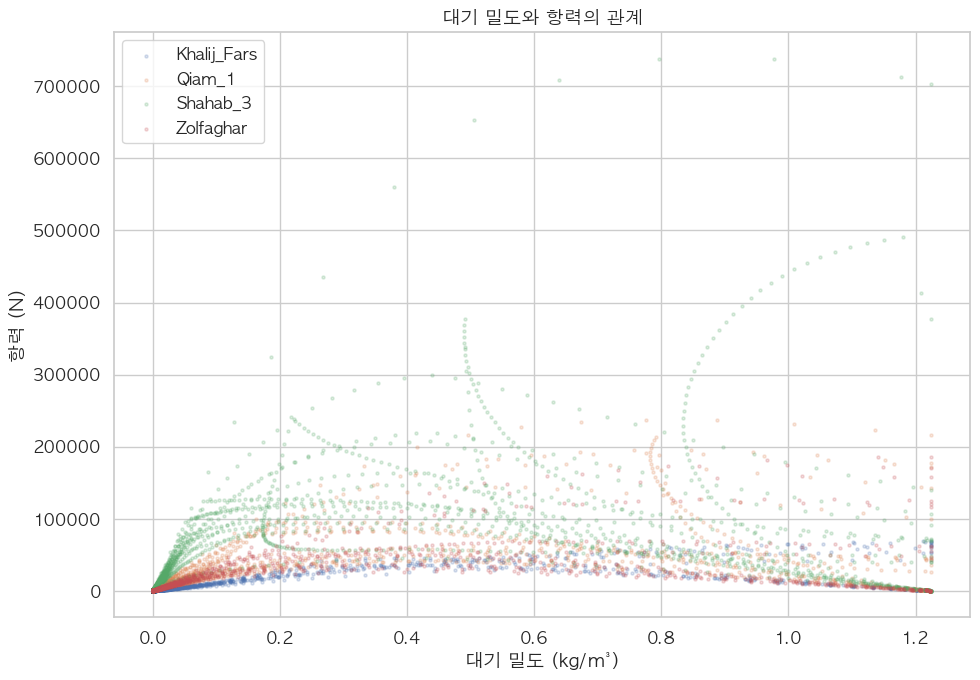

대기밀도-항력 상관계수: 0.44133254419130274


In [102]:
# 7. 대기 밀도와 항력의 관계
fig, ax = plt.subplots(figsize=(10, 7))

for missile_type, missile_data in trajectory_data.groupby("missile_type"):
    ax.scatter(
        missile_data["weather_air_density"],
        missile_data["drag_force"],
        s=5,
        alpha=0.2,
        label=missile_type,
    )

ax.set_title("대기 밀도와 항력의 관계")
ax.set_xlabel("대기 밀도 (kg/m³)")
ax.set_ylabel("항력 (N)")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "대기밀도-항력 상관계수:",
    trajectory_data[["weather_air_density", "drag_force"]].corr().iloc[0, 1],
)

## 15. Descriptive Analysis: 항력과 가속도 변화

질량 소모와 대기 항력이 함께 작용하는 비행 구간에서 가속도 크기가 어떻게 변하는지 고도별로 확인합니다. 대기 밀도-가속도 상관계수와 프로파일을 함께 보되, 추력 연소 구간과 상승·하강 구간을 구분해 해석해야 합니다.

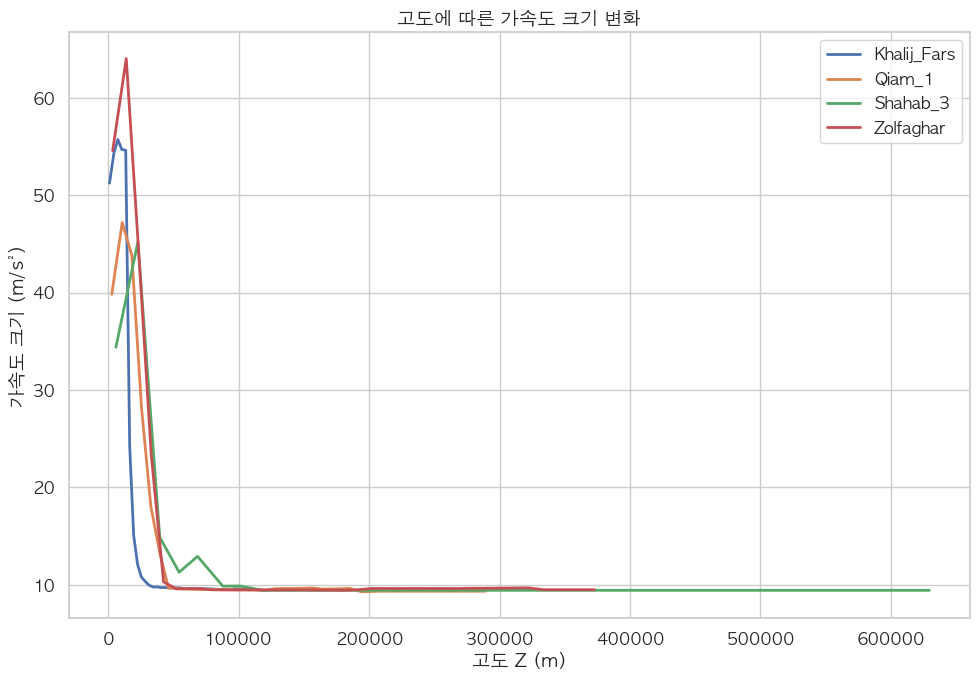

대기밀도-가속도 상관계수: 0.5441278416230527


In [103]:
# 8. 고도에 따른 가속도 크기 변화
fig, ax = plt.subplots(figsize=(10, 7))

for missile_type, missile_data in trajectory_data.groupby("missile_type"):
    profile = (
        missile_data.groupby(pd.cut(missile_data["z"], bins=40), observed=True)
        .agg(
            altitude=("z", "mean"),
            acceleration=("acceleration_magnitude", "mean"),
        )
        .dropna()
    )
    ax.plot(
        profile["altitude"],
        profile["acceleration"],
        linewidth=2,
        label=missile_type,
    )

ax.set_title("고도에 따른 가속도 크기 변화")
ax.set_xlabel("고도 Z (m)")
ax.set_ylabel("가속도 크기 (m/s²)")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "대기밀도-가속도 상관계수:",
    trajectory_data[["weather_air_density", "acceleration_magnitude"]]
    .corr()
    .iloc[0, 1],
)

## 16. Uncertainty & Scatter Analysis: CEP

동일 기종의 여러 Monte Carlo 회차에서 최종 탄착점이 평균 중심 주변에 얼마나 퍼지는지 확인합니다. CEP는 탄착점 중심에서 50%의 회차가 포함되는 원의 반경으로 계산하며, 기종별 환경 불확실성의 공간적 산포를 비교합니다.

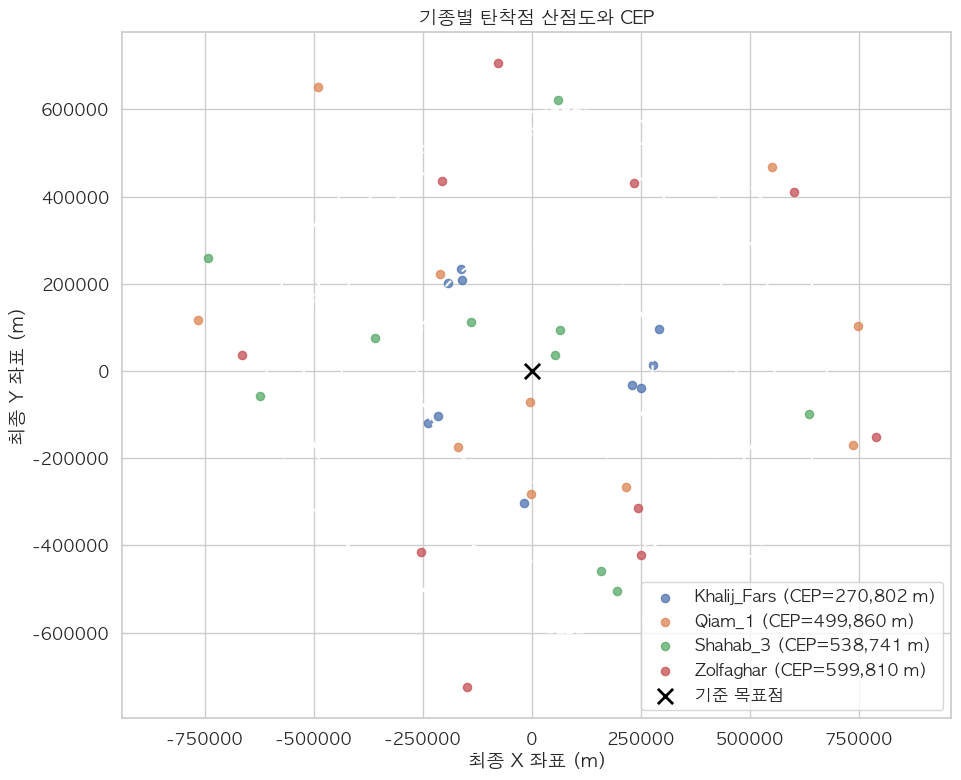

  missile_type  CEP_50_radius
0  Khalij_Fars  270802.282360
1       Qiam_1  499860.445158
2     Shahab_3  538740.858804
3    Zolfaghar  599809.703168


In [104]:
# 9. 기종별 탄착점 산점도와 CEP(50% 반경)
fig, ax = plt.subplots(figsize=(10, 8))
cep_rows = []

for missile_type, missile_data in terminal_data.groupby("missile_type"):
    center_x = missile_data["target_x"].mean()
    center_y = missile_data["target_y"].mean()
    distances = np.hypot(
        missile_data["target_x"] - center_x,
        missile_data["target_y"] - center_y,
    )
    cep = np.percentile(distances, 50)
    cep_rows.append({"missile_type": missile_type, "CEP_50_radius": cep})

    ax.scatter(
        missile_data["target_x"],
        missile_data["target_y"],
        s=35,
        alpha=0.75,
        label=f"{missile_type} (CEP={cep:,.0f} m)",
    )
    cep_circle = plt.Circle(
        (center_x, center_y),
        cep,
        fill=False,
        linestyle="--",
        linewidth=1.5,
    )
    ax.add_patch(cep_circle)

ax.scatter(
    [TARGET_X],
    [TARGET_Y],
    marker="x",
    s=120,
    linewidths=2,
    color="black",
    label="기준 목표점",
)
ax.set_title("기종별 탄착점 산점도와 CEP")
ax.set_xlabel("최종 X 좌표 (m)")
ax.set_ylabel("최종 Y 좌표 (m)")
ax.axis("equal")
ax.legend()
fig.tight_layout()
plt.show()

cep_table = pd.DataFrame(cep_rows).sort_values("CEP_50_radius")
print(cep_table)

## 17. Uncertainty & Scatter Analysis: 탄착 오차 확률분포

`range_error`의 히스토그램과 50·90백분위수를 기종별로 비교합니다. 중앙값은 전형적인 오차 크기를, 90백분위수는 환경 불확실성이 큰 회차에서의 오차 범위를 나타냅니다.

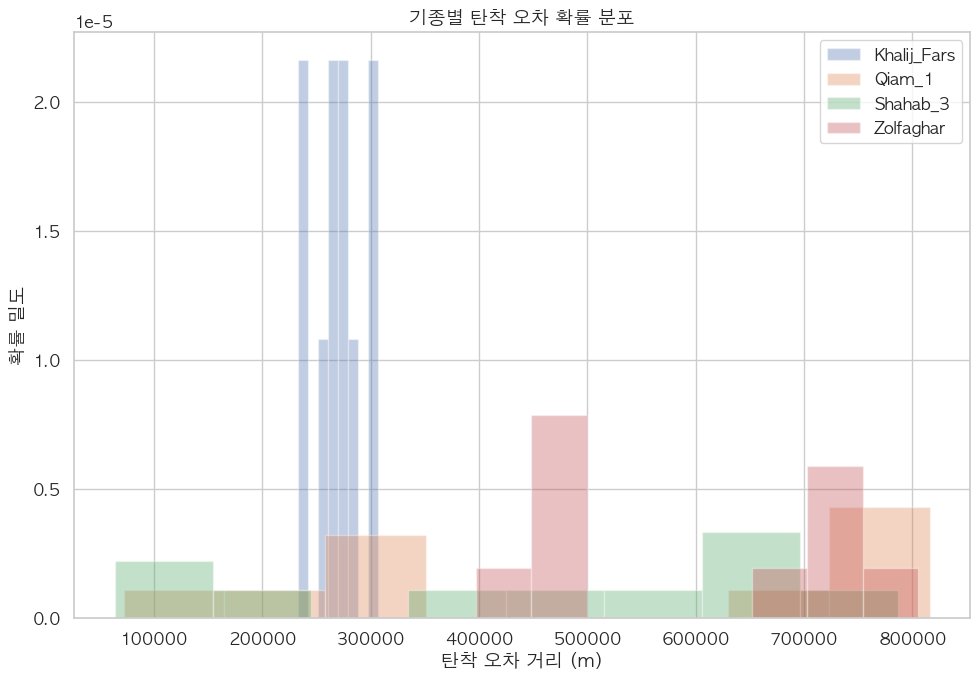

  missile_type      error_p50      error_p90
0  Khalij_Fars  271999.769104  303874.511570
2     Shahab_3  512884.837195  657506.627534
1       Qiam_1  533290.146436  779135.663497
3    Zolfaghar  578790.413706  746142.644194


In [105]:
# 10. 기종별 range_error 확률 분포와 누적 50% 지점
fig, ax = plt.subplots(figsize=(10, 7))
error_quantiles = []

for missile_type, missile_data in terminal_data.groupby("missile_type"):
    errors = missile_data["range_error"].sort_values().to_numpy()
    ax.hist(
        errors,
        bins=8,
        alpha=0.35,
        density=True,
        label=missile_type,
    )
    error_quantiles.append({
        "missile_type": missile_type,
        "error_p50": np.percentile(errors, 50),
        "error_p90": np.percentile(errors, 90),
    })

ax.set_title("기종별 탄착 오차 확률 분포")
ax.set_xlabel("탄착 오차 거리 (m)")
ax.set_ylabel("확률 밀도")
ax.legend()
fig.tight_layout()
plt.show()

error_summary = pd.DataFrame(error_quantiles).sort_values("error_p50")
print(error_summary)

## 18. 결론 도출 시 주의사항

이 노트북의 결론은 RocketPy 내부에서 계산된 상태 변수와 Monte Carlo 입력 변수를 연결해 물리적 경향을 확인하는 데 목적이 있습니다.

- Pearson 상관계수는 선형 연관성의 지표이며 인과관계를 단독으로 증명하지 않습니다.
- 현재 결과는 기종당 10회인 파이프라인 검증용 표본입니다. 최종 결론에는 기종당 10,000회 수준의 표본과 신뢰구간이 필요합니다.
- 항력과 가속도는 대기 밀도뿐 아니라 속도, 질량, 추력, 공기저항계수의 영향을 동시에 받습니다.
- CEP는 각 기종의 탄착점 평균 중심 기준으로 계산되며, 기준 목표점과의 평균 오차인 `range_error`와는 다른 지표입니다.
- 따라서 민감도 분석, 기종 비교, 대기 모델 검증, CEP 분석을 함께 사용해 결론을 도출합니다.